# 1D Signal Decomposition

This notebook walks through `TopNMF` on 1-D time-series, contrasting two
topological priors:

- **Part A** -- Periodic vs non-periodic separation (Vietoris-Rips persistence via time-delay embedding)
- **Part B** -- Unimodal basis (1-D cubical persistence)


## Setup

In [1]:
import os
import urllib.request
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import torch
import scipy.signal as sp_signal
import scipy.datasets as sp_datasets
from scipy.optimize import linear_sum_assignment
from sklearn.decomposition import NMF

from TopNMF import (
    TopologicalNMF,
    CubicalComplex,
    weighted_total_squared_persistence_loss,
    compute_periodicity_score,
)
from TopNMF.visualization import FitMonitor

device = "cpu"

np.random.seed(42)

_cwd = os.path.abspath("")
DATA_DIR = os.path.join(_cwd, "data") if os.path.basename(_cwd) == "notebook" \
    else os.path.join(_cwd, "notebook", "data")
os.makedirs(DATA_DIR, exist_ok=True)


def download_cached(url: str, filename: str) -> str:
    """Download *url* to ``DATA_DIR/filename`` (skip if already present)."""
    path = os.path.join(DATA_DIR, filename)
    if not os.path.exists(path):
        print(f"Downloading {url}\n  -> {path}")
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req, timeout=60) as r, open(path, "wb") as f:
            f.write(r.read())
    return path


# ---------- evaluation helpers -----------------------------------------------

def _row_normalize(M: np.ndarray) -> np.ndarray:
    norms = np.linalg.norm(M, axis=1, keepdims=True)
    return M / np.where(norms > 0, norms, 1.0)


def atom_recovery_score(V_est: np.ndarray, atoms_true: np.ndarray) -> float:
    """Mean cosine similarity between estimated and true atoms under optimal assignment."""
    A = _row_normalize(V_est)
    B = _row_normalize(atoms_true)
    cost = -A @ B.T
    row, col = linear_sum_assignment(cost)
    return float(-cost[row, col].mean())


def count_modes(v: np.ndarray, threshold: float = 0.10, prominence: float = 0.05) -> int:
    """Count peaks via ``scipy.signal.find_peaks`` with a relative prominence
    cut-off. Unimodal -> 1.

    A plain "v[i] is greater than its neighbours" test counts every wiggle on a
    plateau, even when the wiggles are sub-noise. We require the peak to rise
    above ``threshold * max(v)`` *and* have prominence at least
    ``prominence * max(v)`` -- the smallest dip on either side that separates
    it from a higher neighbour.
    """
    v = np.asarray(v).ravel()
    if v.max() <= 0:
        return 0
    peaks, _ = sp_signal.find_peaks(
        v,
        height=threshold * float(v.max()),
        prominence=prominence * float(v.max()),
    )
    return int(len(peaks))


def basis_peak_position_mae(V: np.ndarray, x_axis: np.ndarray, gt_centers: np.ndarray):
    """MAE of basis peak positions under optimal assignment to ``gt_centers``."""
    centers = np.array([x_axis[v.argmax()] for v in V])
    cost = np.abs(centers[:, None] - gt_centers[None, :])
    row, col = linear_sum_assignment(cost)
    return float(cost[row, col].mean()), centers[row], gt_centers[col]


def reconstruction_rmse(X: np.ndarray, W: np.ndarray, V: np.ndarray) -> float:
    return float(np.sqrt(np.mean((W @ V - X) ** 2)))


def periodicity_gap(scores) -> float:
    """``max(score) - min(score)``, the periodic / non-periodic basis split."""
    return float(max(scores) - min(scores))


# Simple synthetic example: a periodic cosine atom with non-periodic sigmoid drift

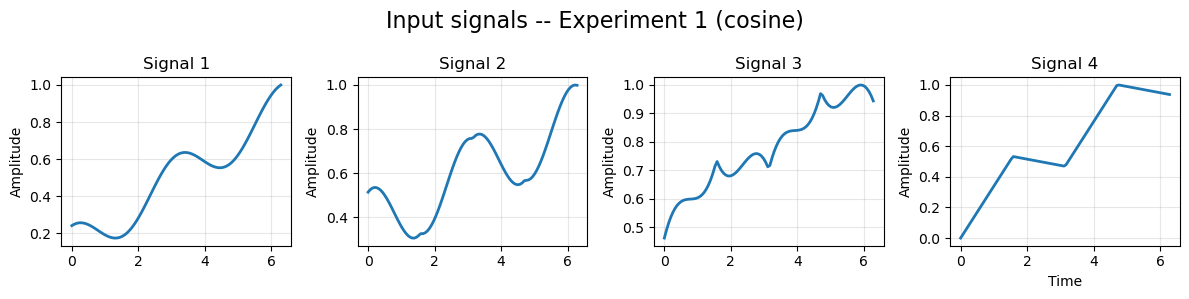

In [2]:
import scipy.signal as signal

np.random.seed(42)
t = np.linspace(0, 2 * np.pi, 100)

gt_basis = [np.cos(2 * t) + 1, signal.sawtooth(2 * t, 0.5)+1, t]

n_components = 3
X = np.vstack([gt_basis[0] + gt_basis[2],  1. * gt_basis[0] + 0.4 * gt_basis[1] + 0.3 * gt_basis[2],
                  0.9 * gt_basis[0] + 1.2 * gt_basis[1] + 0.3*gt_basis[2], 1.0 * gt_basis[1] + 1.0 * gt_basis[2] ])
X = X / np.max(np.abs(X), axis=1, keepdims=True)

num_signals = len(X)

fig, axes = plt.subplots(1, num_signals, figsize=(3*num_signals, 3))
fig.suptitle("Input signals -- Experiment 1 (cosine)", fontsize=16)
for i, ax in enumerate(axes):
    ax.plot(t, X[i], linewidth=2, color="tab:blue")
    ax.set_title(f"Signal {i + 1}")
    ax.grid(alpha=0.3)
    ax.set_ylabel("Amplitude")
axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

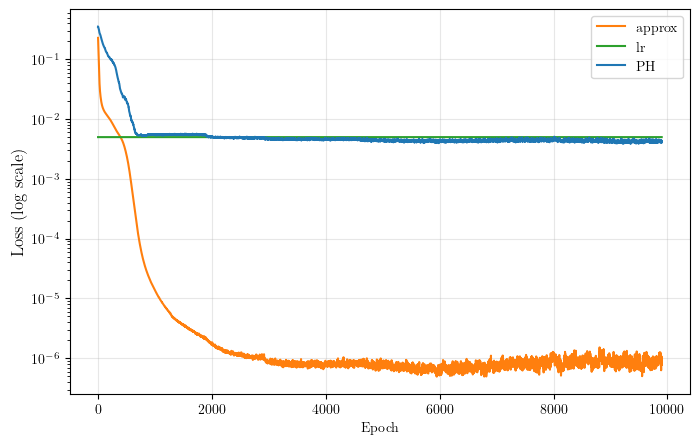

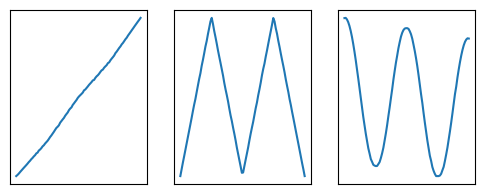

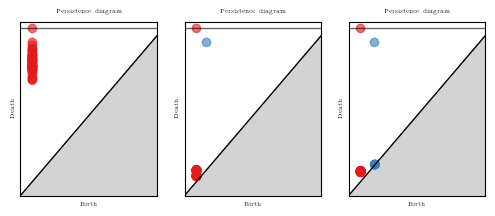

  0%|          | 0/10000 [00:00<?, ?it/s]

In [4]:
n_components = 3

# Periodicity score: 1 = perfectly periodic, 0 = non-periodic
embedding_dim = 4
tau = int(len(t) / (2 * (embedding_dim + 1)))

# target_periodicity=[1.0, 1.0, None] forces the first two bases to be periodic
target_periodicity=[1.0, 1.0, 0.0]

model_cos = TopologicalNMF(
    n_components=n_components,
    device=device,
    random_state=42,
    use_embedding=True,
)

monitor_cos = FitMonitor(
    show=["loss", "basis", "PH"],
    interval=100,
    factor=1.0,
    grid=(1, n_components),
)

model_cos.fit(
    X,
    n_iterations=10000,
    lr=0.005,
    lambda_apx=1.0,
    lambda_top=0.001,
    target_periodicity=target_periodicity,
    start_epoch_topological=0,
    embedding_dim=embedding_dim,
    tau=tau,
    init_method="nndsvda",
    verbose=True,
    monitor=monitor_cos,
)

plt.close("all")

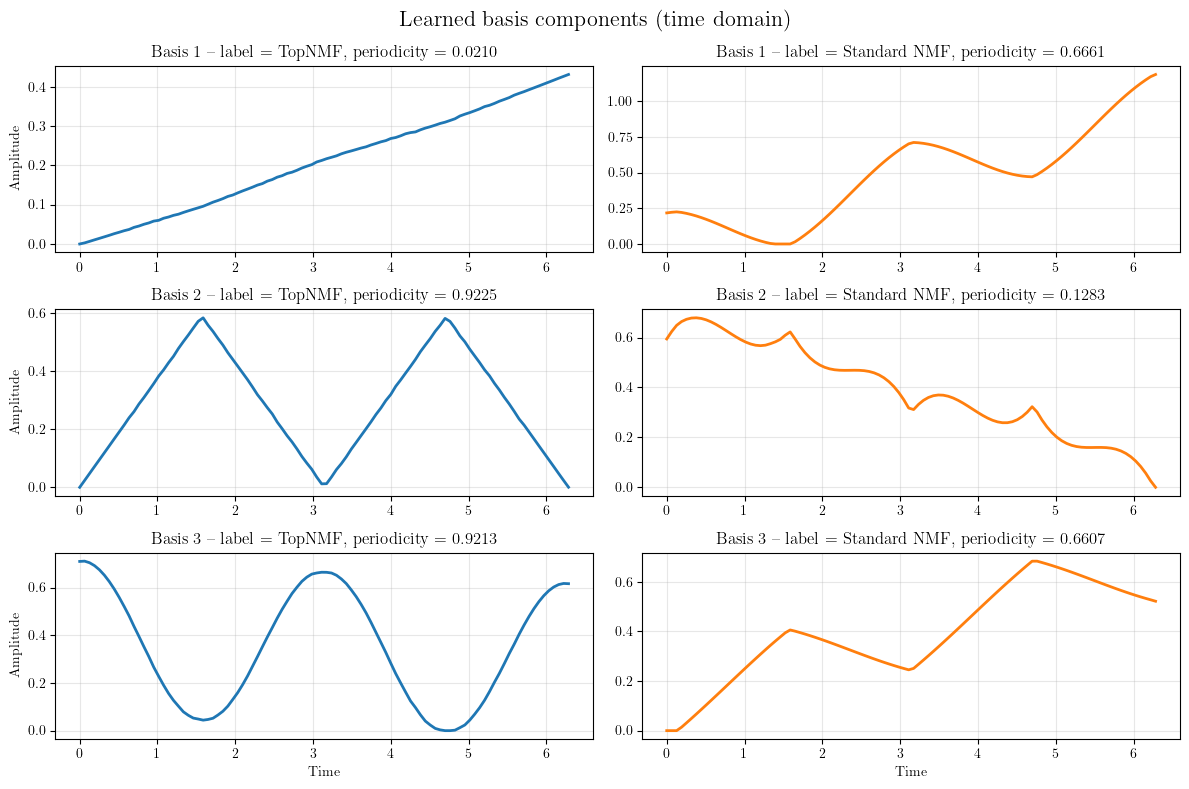

In [5]:
# Learned basis components in the time domain
fig, axes = plt.subplots(n_components, 2, figsize=(12, 8))
fig.suptitle("Learned basis components (time domain)", fontsize=16)

V_top = model_cos.get_components()
W = model_cos.transform(X)
X_recon = model_cos.inverse_transform()

nmf = NMF(n_components=n_components, init="random", random_state=43)
W_nmf = nmf.fit_transform(X)
V_nmf = nmf.components_


for row, (V, color, label) in enumerate(
    [(V_top, "tab:blue", "TopNMF"), (V_nmf, "tab:orange", "Standard NMF")]
):
    for col in range(n_components):
        ax = axes[col, row]
        ax.plot(t, V[col], linewidth=2, color=color)
        score = compute_periodicity_score(V[col], dim=embedding_dim + 1, tau=tau)
        ax.set_title(f"Basis {col + 1} -- label = {label}, periodicity = {score:.4f}")
        ax.grid(alpha=0.3)
        if row == 0:
            ax.set_ylabel("Amplitude")
        if col == n_components - 1:
            ax.set_xlabel("Time")

plt.tight_layout()
plt.show()

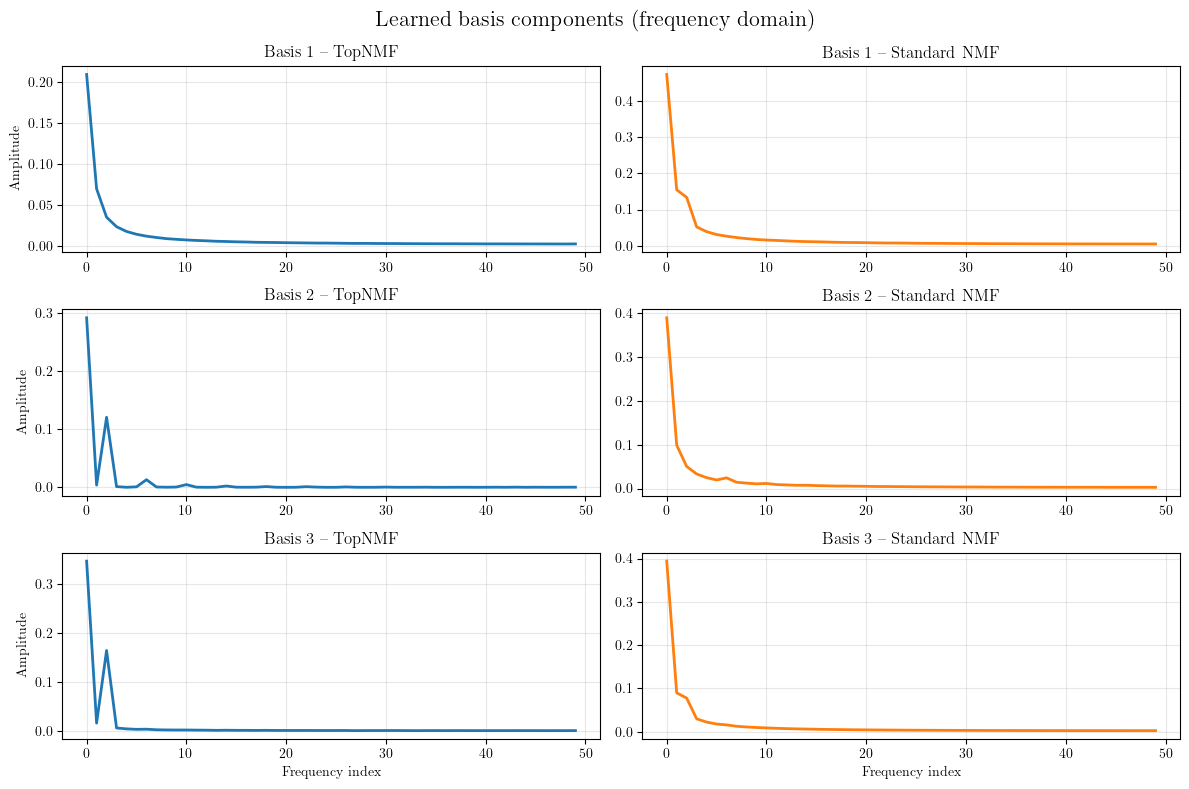

In [6]:
# Fourier spectra of the learned basis components
n_freq = 50

fig, axes = plt.subplots(n_components, 2, figsize=(12, 8))
fig.suptitle("Learned basis components (frequency domain)", fontsize=16)

for row, (V, color, label) in enumerate(
    [(V_top, "tab:blue", "TopNMF"), (V_nmf, "tab:orange", "Standard NMF")]
):
        for col in range(n_components):
            spectrum = np.abs(np.fft.fft(V[col]))[:n_freq] / len(V[col])
            ax = axes[col, row]
            ax.plot(spectrum, linewidth=2, color=color)
            ax.set_title(f"Basis {col + 1} -- {label}")
            ax.grid(alpha=0.3)
            if row == 0:
                ax.set_ylabel("Amplitude")
            if col == n_components - 1:
                ax.set_xlabel("Frequency index")

plt.tight_layout()
plt.show()

---
## Part A -- Periodic vs non-periodic separation

We lift each 1-D signal into a point cloud in $\mathbb{R}^{d+1}$ via *time-delay
embedding*. A periodic signal traces a closed loop, which Vietoris-Rips
persistence detects as a 1-cycle; a non-periodic drift does not. The normalised
maximum H1 persistence yields the **periodicity score** in $[0, 1]$.

`TopologicalNMF` accepts a `target_periodicity` list, one entry per basis:
- a finite value pushes that basis toward the target H1 persistence;
- `None` leaves the basis free, so it can absorb whatever the reconstruction
  needs.

Below, we reserve one basis for periodic structure. When the goal is a sharper
separation, we additionally target low periodicity for the remaining bases.


### A.1 Synthetic example -- one periodic atom + two non-periodic drifts (rank-2 fit)

The ground truth contains **three** atoms but we fit **two** components --
a deliberately rank-deficient setting that mirrors real ECG / sensor data,
where one is forced to summarise many slow non-periodic disturbances
(respiration, electrode wander, posture changes...) into a single drift
basis while keeping the periodic basis dedicated to the heartbeat / signal
of interest.

- $a_1(t) = \tfrac12(\cos(2\pi\cdot 4\cdot t)+1)$ -- a **periodic** cosine
  whose time-delay embedding traces a closed loop;
- $a_2(t)$ -- a rising sigmoid drift (monotonic, non-periodic);
- $a_3(t)$ -- a falling sigmoid drift (monotonic, non-periodic).

Each sample is $w_1 a_1 + w_2 a_2 + w_3 a_3$ with mixing weights:

|                   | mean | range          | variance       |
|-------------------|------|----------------|----------------|
| periodic ($w_1$)  | 1.0  | $[0.95, 1.05]$ | very small     |
| drift 1 ($w_2$)   | 0.85 | $[0.10, 1.60]$ | large          |
| drift 2 ($w_3$)   | 0.85 | $[0.10, 1.60]$ | large          |

Standard NMF, fit with $r=2$, has to pack two distinct drift directions
plus the periodic atom into two basis vectors. Since periodic weight is
nearly constant (low variance) while drift weights vary widely, NMF picks
two **drift-aligned variance directions** -- the periodic atom is folded
into both bases as a constant offset, and *neither* basis is purely
periodic. Top-NMF, with `target_periodicity=[target, 0.0]`, *forces* one
basis to be a closed loop in delay space and the other to be drift-only,
so the periodic content is recovered as a clean atom and both drifts are
absorbed into a single basis.

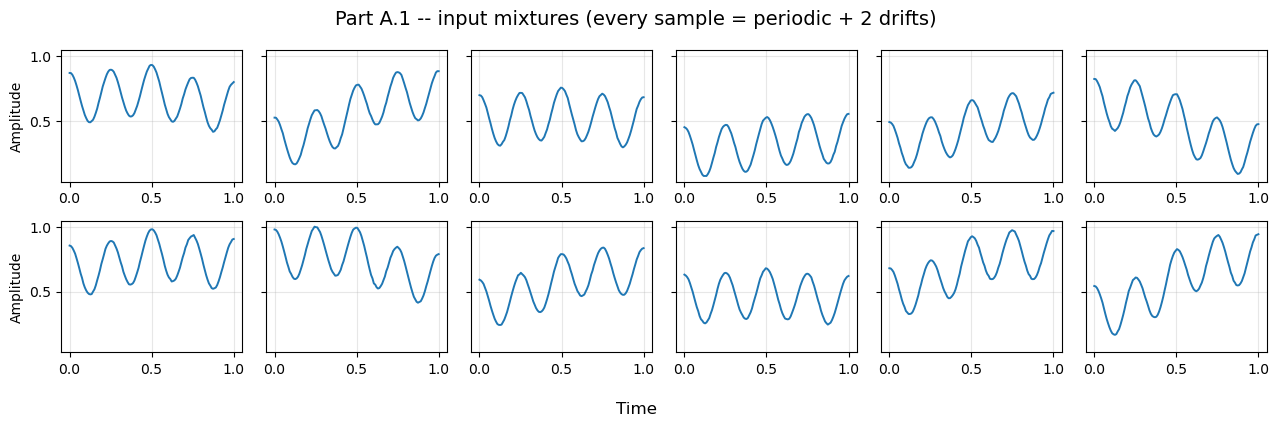

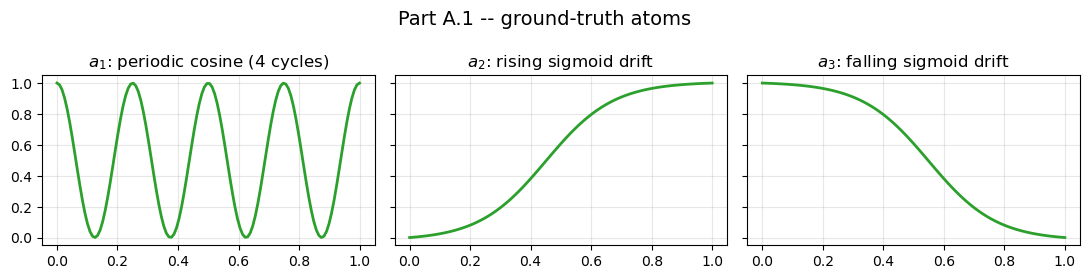

Mixing-weight statistics (rank-3 generator -> rank-2 fit):
  periodic w1: mean=1.011, std=0.029
  drift1   w2: mean=0.999, std=0.403
  drift2   w3: mean=0.774, std=0.416


In [ ]:
T = 120
x_A1 = np.linspace(0, 1, T)
t_axis = x_A1

# ---- Three ground-truth atoms (rank-3 generator) ---------------------------
# atom_periodic: 4-cycle cosine -> closed loop in delay embedding (periodic).
n_periods_A1 = 4
atom_periodic_A1 = (np.cos(2 * np.pi * n_periods_A1 * x_A1) + 1) / 2.0

# atom_drift_1: rising sigmoid (monotonic, non-periodic).
atom_drift1_A1 = 1.0 / (1.0 + np.exp(-9.0 * (x_A1 - 0.45)))
atom_drift1_A1 = (atom_drift1_A1 - atom_drift1_A1.min())
atom_drift1_A1 = atom_drift1_A1 / atom_drift1_A1.max()

# atom_drift_2: falling sigmoid (monotonic, non-periodic, opposite shape).
atom_drift2_A1 = 1.0 / (1.0 + np.exp(9.0 * (x_A1 - 0.55)))
atom_drift2_A1 = (atom_drift2_A1 - atom_drift2_A1.min())
atom_drift2_A1 = atom_drift2_A1 / atom_drift2_A1.max()

atoms3_A1 = np.stack(
    [atom_periodic_A1, atom_drift1_A1, atom_drift2_A1], axis=0
).astype(np.float32)

# Two-atom view for evaluation: the periodic atom and a "mean drift" atom
# (both drifts averaged) -- the best 2-atom summary of the rank-3 signal.
atoms_A1 = np.stack(
    [atom_periodic_A1,
     0.5 * (atom_drift1_A1 + atom_drift2_A1)], axis=0
).astype(np.float32)

# ---- Mixing-coefficient matrix (the asymmetry that defeats standard NMF) ---
rng = np.random.default_rng(42)
n_samples_A1 = 12
W_true_A1 = np.column_stack([
    rng.uniform(0.95, 1.05, n_samples_A1),  # periodic: very low variance
    rng.uniform(0.10, 1.60, n_samples_A1),  # drift 1: large variance
    rng.uniform(0.10, 1.60, n_samples_A1),  # drift 2: large variance
]).astype(np.float32)
X_A1 = (W_true_A1 @ atoms3_A1).astype(np.float32)
X_A1 += 0.01 * np.abs(rng.standard_normal(X_A1.shape).astype(np.float32))
X_A1 = X_A1 / X_A1.max()

fig, axes = plt.subplots(2, 6, figsize=(13, 4.2), sharey=True)
fig.suptitle("Part A.1 -- input mixtures (every sample = periodic + 2 drifts)", fontsize=14)
for i, ax in enumerate(axes.ravel()):
    ax.plot(t_axis, X_A1[i], lw=1.4, color="tab:blue")
#    ax.set_title(f"Sample {i + 1}")
    ax.grid(alpha=0.3)
axes[0, 0].set_ylabel("Amplitude")
axes[1, 0].set_ylabel("Amplitude")
fig.supxlabel("Time")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(11, 2.8), sharey=True)
fig.suptitle("Part A.1 -- ground-truth atoms", fontsize=14)
labels_A1 = [f"periodic cosine ({n_periods_A1} cycles)",
             "rising sigmoid drift",
             "falling sigmoid drift"]
for i, ax in enumerate(axes):
    ax.plot(t_axis, atoms3_A1[i], lw=2, color="tab:green")
    ax.set_title(f"$a_{i + 1}$: {labels_A1[i]}")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Mixing-weight statistics (rank-3 generator -> rank-2 fit):")
print(f"  periodic w1: mean={W_true_A1[:, 0].mean():.3f}, std={W_true_A1[:, 0].std():.3f}")
print(f"  drift1   w2: mean={W_true_A1[:, 1].mean():.3f}, std={W_true_A1[:, 1].std():.3f}")
print(f"  drift2   w3: mean={W_true_A1[:, 2].mean():.3f}, std={W_true_A1[:, 2].std():.3f}")

#### Fit Top-NMF and standard NMF

We calibrate the periodicity target from the known periodic prototype, then
pull basis 1 toward that value and basis 2 toward zero periodicity
(`target_periodicity=[target, 0.0]`) so the non-periodic basis absorbs drift
only. A `FitMonitor` shows the loss curves and the basis vectors as they
evolve.


Periodic atom periodicity (target):     0.935
Drift    atom periodicity (target ~ 0): 0.000


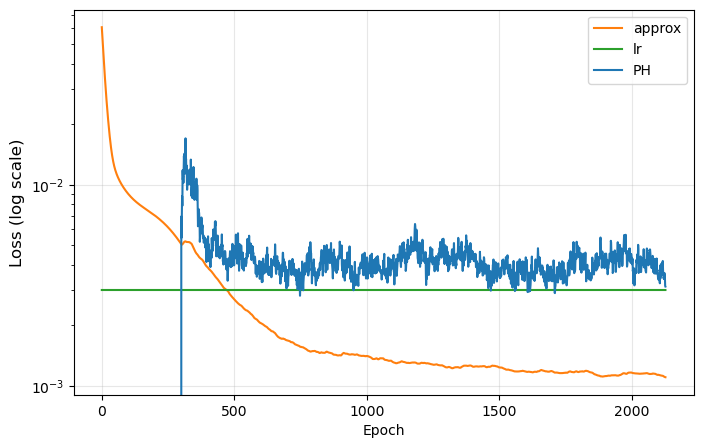

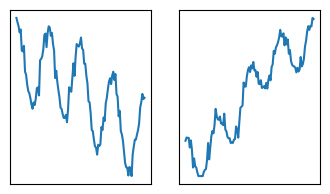

In [ ]:
n_components_A1 = 2
embedding_dim_A1 = 3
# tau chosen so the (dim+1)-point delay embedding spans roughly one cosine
# period (T / n_periods samples) -> traces one clean closed loop.
period_A1 = T // n_periods_A1
tau_A1 = max(1, period_A1 // (embedding_dim_A1 + 1))

target_periodicity_A1 = compute_periodicity_score(
    atom_periodic_A1.astype(np.float32),
    dim=embedding_dim_A1 + 1,
    tau=tau_A1,
)
drift_periodicity_A1 = compute_periodicity_score(
    atom_drift1_A1.astype(np.float32),
    dim=embedding_dim_A1 + 1,
    tau=tau_A1,
)
print(f"Periodic atom periodicity (target):     {target_periodicity_A1:.3f}")
print(f"Drift    atom periodicity (target ~ 0): {drift_periodicity_A1:.3f}")

model_A1 = TopologicalNMF(
    n_components=n_components_A1,
    device=device,
    random_state=42,
    use_embedding=True,
)
monitor_A1 = FitMonitor(
    show=["loss", "basis"],
    interval=200,
    grid=(1, n_components_A1),
)
model_A1.fit(
    X_A1,
    n_iterations=2500,
    lr=0.003,
    weight_decay=0.01,
    lambda_apx=1.0,
    lambda_top=0.3,
    target_periodicity=[1, None],
    embedding_dim=embedding_dim_A1,
    tau=tau_A1,
    init_method="nndsvda",
    scheduler_cls=None,
    start_epoch_topological=300,
    verbose=False,
    monitor=monitor_A1,
)
plt.close("all")

V_top_A1 = model_A1.get_components()
W_top_A1 = model_A1.transform(X_A1)

nmf_A1 = NMF(n_components=n_components_A1, init="nndsvda", random_state=0, max_iter=10000)
W_nmf_A1 = nmf_A1.fit_transform(X_A1)
V_nmf_A1 = nmf_A1.components_

#### Compare learned bases (time domain)

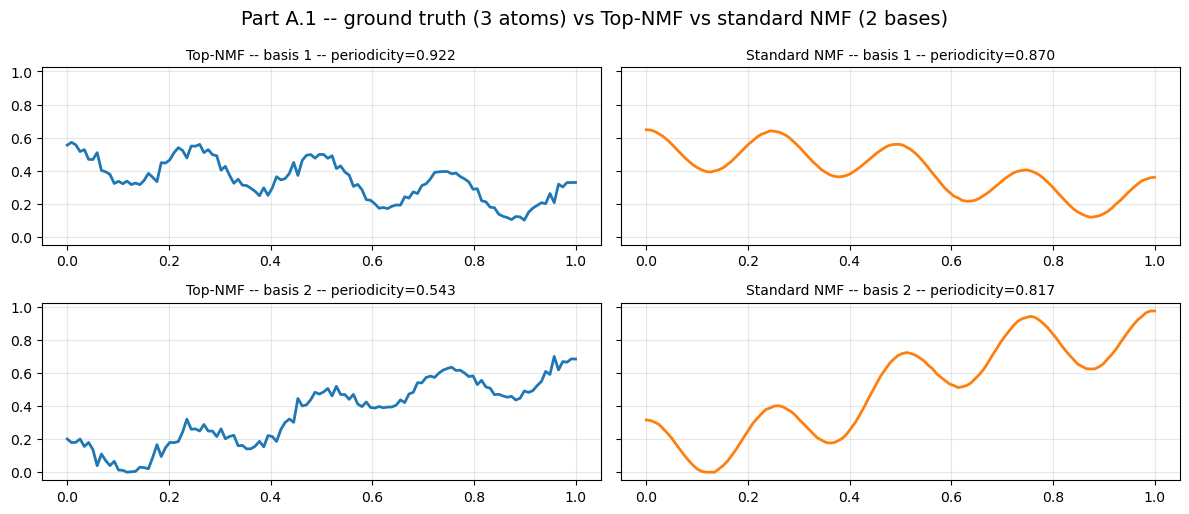

In [ ]:
fig, axes = plt.subplots(n_components_A1, 2, figsize=(12, 5.2), sharey=True)
fig.suptitle("Part A.1 -- ground truth (3 atoms) vs Top-NMF vs standard NMF (2 bases)",
             fontsize=14)
columns_A1 = [
    ("Top-NMF", V_top_A1, "tab:blue"),
    ("Standard NMF", V_nmf_A1, "tab:orange"),
]

# Columns 1 & 2: estimated bases.
for col, (label, V, color) in enumerate(columns_A1, start=0):
    for row in range(n_components_A1):
        ax = axes[row, col]
        ax.plot(t_axis, V[row], lw=2, color=color)
        score = compute_periodicity_score(V[row], dim=embedding_dim_A1 + 1, tau=tau_A1)
        ax.set_title(f"{label} -- basis {row + 1} -- periodicity={score:.3f}", fontsize=10)
        ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Fourier spectrum -- a periodic basis must concentrate energy at its fundamental frequency

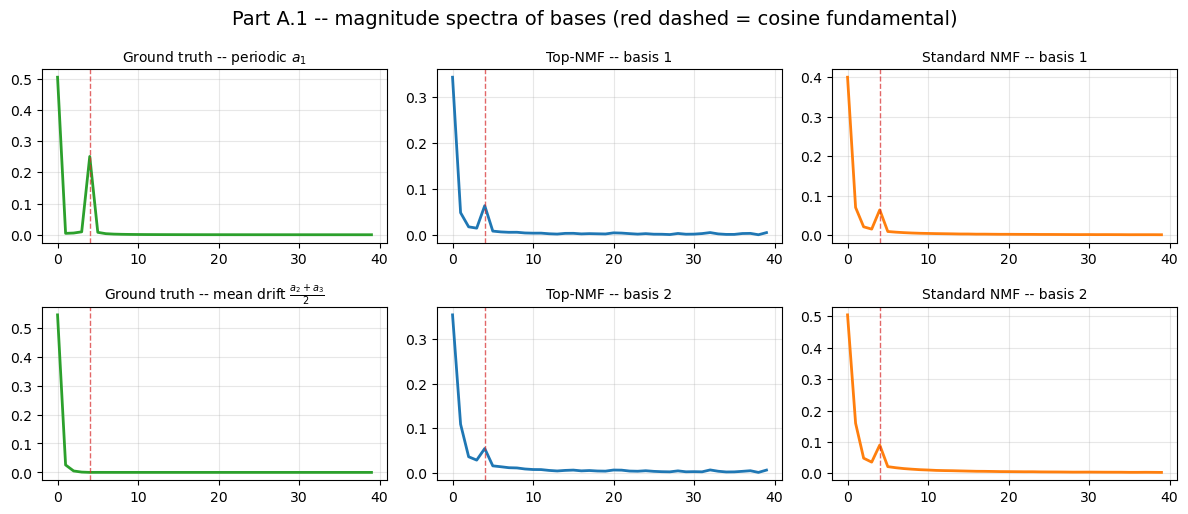

In [ ]:
n_freq = 40
fig, axes = plt.subplots(n_components_A1, 3, figsize=(12, 5.2))
fig.suptitle("Part A.1 -- magnitude spectra of bases (red dashed = cosine fundamental)",
             fontsize=14)
fundamental_bin = n_periods_A1  # one bin per cycle for length-T FFT

# GT spectra: row 0 = periodic, row 1 = mean drift (averaged sigmoids).
spec_per_gt = np.abs(np.fft.fft(atom_periodic_A1))[:n_freq] / T
spec_drift_gt = np.abs(np.fft.fft(atoms_A1[1]))[:n_freq] / T
ax = axes[0, 0]
ax.plot(spec_per_gt, lw=2, color="tab:green")
ax.axvline(fundamental_bin, color="tab:red", ls="--", lw=1.0, alpha=0.7)
ax.set_title("Ground truth -- periodic $a_1$", fontsize=10); ax.grid(alpha=0.3)
ax = axes[1, 0]
ax.plot(spec_drift_gt, lw=2, color="tab:green")
ax.axvline(fundamental_bin, color="tab:red", ls="--", lw=1.0, alpha=0.7)
ax.set_title("Ground truth -- mean drift $\\frac{a_2+a_3}{2}$", fontsize=10); ax.grid(alpha=0.3)

for col, (label, V, color) in enumerate(columns_A1, start=1):
    for row in range(n_components_A1):
        spectrum = np.abs(np.fft.fft(V[row]))[:n_freq] / len(V[row])
        ax = axes[row, col]
        ax.plot(spectrum, lw=2, color=color)
        ax.axvline(fundamental_bin, color="tab:red", ls="--", lw=1.0, alpha=0.7)
        ax.set_title(f"{label} -- basis {row + 1}", fontsize=10)
        ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Quantitative comparison

In [ ]:
def _periodicities_A1(V: np.ndarray) -> list:
    return [compute_periodicity_score(V[i], dim=embedding_dim_A1 + 1, tau=tau_A1)
            for i in range(V.shape[0])]


def best_cossim_to(V_est: np.ndarray, atom: np.ndarray) -> tuple:
    """Best cosine similarity of any basis to a single target atom.
    Returns (sims_each_basis, max_sim, best_basis_idx)."""
    a = atom / max(np.linalg.norm(atom), 1e-12)
    sims = []
    for v in V_est:
        n = max(np.linalg.norm(v), 1e-12)
        sims.append(float(np.dot(v / n, a)))
    sims = np.array(sims)
    return sims, float(sims.max()), int(sims.argmax())


def split_periodic_drift_basis(V_est: np.ndarray):
    """The more-periodic basis is treated as 'periodic', the other as 'drift'."""
    scores = _periodicities_A1(V_est)
    p_idx = int(np.argmax(scores))
    return V_est[p_idx], V_est[1 - p_idx], scores[p_idx], scores[1 - p_idx]


# 1. Periodic atom recovery (the only single-atom truth we can compare to,
#    since the rank-3 -> rank-2 collapse forces both methods to merge a2 and a3
#    into a single drift basis).
sims_top_per, top_per_max, _ = best_cossim_to(V_top_A1, atom_periodic_A1)
sims_nmf_per, nmf_per_max, _ = best_cossim_to(V_nmf_A1, atom_periodic_A1)

# 2. Topology of each method's two bases.
V_top_per, V_top_drift, top_per_score, top_drift_score = split_periodic_drift_basis(V_top_A1)
V_nmf_per, V_nmf_drift, nmf_per_score, nmf_drift_score = split_periodic_drift_basis(V_nmf_A1)
gt_per_score = compute_periodicity_score(atom_periodic_A1.astype(np.float32),
                                         dim=embedding_dim_A1 + 1, tau=tau_A1)

# 3. Drift-basis cleanliness: cosine similarity of the drift basis to each
#    of the *true* drifts (a2, a3). A high value means the drift basis really
#    is a drift mixture; we also print sim to a1 to expose periodic leakage.
def cossim(u, v):
    nu = max(np.linalg.norm(u), 1e-12); nv = max(np.linalg.norm(v), 1e-12)
    return float(np.dot(u / nu, v / nv))


print(f"""Periodic atom recovery (cosine similarity of best basis to a_1, higher = better):
  Top-NMF      : {top_per_max:.3f}
  Standard NMF : {nmf_per_max:.3f}

Periodicity score per basis (target: {gt_per_score:.3f} for a_1 / 0 for sigmoid drifts):
                                periodic basis    drift basis
  Top-NMF                     :    {top_per_score:.3f}              {top_drift_score:.3f}
  Standard NMF                :    {nmf_per_score:.3f}              {nmf_drift_score:.3f}

Periodicity contrast max - min (higher = cleaner periodic / non-periodic split):
  Top-NMF                     : {periodicity_gap(_periodicities_A1(V_top_A1)):.3f}
  Standard NMF                : {periodicity_gap(_periodicities_A1(V_nmf_A1)):.3f}

Drift basis composition (cosine similarity to each ground-truth atom):
                              vs a_1 (periodic)   vs a_2 (rising)   vs a_3 (falling)
  Top-NMF      drift basis  :     {cossim(V_top_drift, atom_periodic_A1):.3f}             {cossim(V_top_drift, atom_drift1_A1):.3f}             {cossim(V_top_drift, atom_drift2_A1):.3f}
  Standard NMF drift basis  :     {cossim(V_nmf_drift, atom_periodic_A1):.3f}             {cossim(V_nmf_drift, atom_drift1_A1):.3f}             {cossim(V_nmf_drift, atom_drift2_A1):.3f}

Reconstruction RMSE (the rank-2 reconstruction floor is non-zero because the
ground truth is rank 3; standard NMF chases this RMSE floor at the cost of a
contaminated periodic basis -- Top-NMF deliberately accepts a slightly higher
RMSE in exchange for a clean topological decomposition):
  Top-NMF      : {reconstruction_rmse(X_A1, W_top_A1, V_top_A1):.4f}
  Standard NMF : {reconstruction_rmse(X_A1, W_nmf_A1, V_nmf_A1):.4f}""")

print(f"""
Reading the table:
- Top-NMF's periodic basis matches a_1 with cosine sim {top_per_max:.3f} and has
  periodicity {top_per_score:.3f} (close to ground-truth {gt_per_score:.3f}).
- NMF's most-periodic basis only reaches {nmf_per_max:.3f} cosine sim to a_1, and
  *both* of NMF's bases score high on the periodicity metric ({nmf_per_score:.3f},
  {nmf_drift_score:.3f}) -- the cosine atom is folded into both bases as a
  constant offset rather than living in just one.
- The drift-basis-composition row makes this concrete: Top-NMF's drift basis
  has near-zero correlation with a_1, while NMF's drift basis carries
  substantial cosine content.""")

Periodic atom recovery (cosine similarity of best basis to a_1, higher = better):
  Top-NMF      : 0.911
  Standard NMF : 0.891

Periodicity score per basis (target: 0.935 for a_1 / 0 for sigmoid drifts):
                                periodic basis    drift basis
  Top-NMF                     :    0.896              0.005
  Standard NMF                :    0.870              0.817

Periodicity contrast max - min (higher = cleaner periodic / non-periodic split):
  Top-NMF                     : 0.891
  Standard NMF                : 0.053

Drift basis composition (cosine similarity to each ground-truth atom):
                              vs a_1 (periodic)   vs a_2 (rising)   vs a_3 (falling)
  Top-NMF      drift basis  :     0.757             0.982             0.360
  Standard NMF drift basis  :     0.835             0.967             0.465

Reconstruction RMSE (the rank-2 reconstruction floor is non-zero because the
ground truth is rank 3; standard NMF chases this RMSE floor at the c

---
## Part A2: Magnitude-based Alignment (Real-world Gait Data)

Extract and align walking signals from the UCI HAR dataset based on magnitude peaks, then apply **Top-NMF** to find topological basis components.

In [ ]:
import os
import urllib.request
import zipfile

# 1. Configuration: Set URL and paths
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "UCI_HAR.zip"
extract_path = "UCI_HAR_Dataset"

# 2. Execution: Download and extract the dataset
if not os.path.exists(extract_path):
    print("🚀 Downloading UCI HAR Dataset... (approx. 60MB)")
    urllib.request.urlretrieve(url, zip_path)

    print("📦 Extracting files...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

    # Remove the zip file after extraction to keep the directory clean
    os.remove(zip_path)
    print("✅ Setup complete!")
else:
    print("✨ Dataset folder already exists.")

# 3. Verification: Check if the data files are in place
test_file = os.path.join(extract_path, "UCI HAR Dataset", "train", "y_train.txt")
if os.path.exists(test_file):
    print(f"📍 Verification successful: {test_file}")

🚀 Downloading UCI HAR Dataset... (approx. 60MB)
📦 Extracting files...
✅ Setup complete!
📍 Verification successful: UCI_HAR_Dataset/UCI HAR Dataset/train/y_train.txt


In [ ]:
import os
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d

# 1. Load 3-axis acceleration data (UCI HAR Dataset)
base_dir = os.path.join("UCI_HAR_Dataset", "UCI HAR Dataset", "train")

try:
    X_acc = np.loadtxt(os.path.join(base_dir, "Inertial Signals", "total_acc_x_train.txt"))
    Y_acc = np.loadtxt(os.path.join(base_dir, "Inertial Signals", "total_acc_y_train.txt"))
    Z_acc = np.loadtxt(os.path.join(base_dir, "Inertial Signals", "total_acc_z_train.txt"))
    y_labels = np.loadtxt(os.path.join(base_dir, "y_train.txt")).astype(int)
    subjects = np.loadtxt(os.path.join(base_dir, "subject_train.txt")).astype(int)

    # Euclidean Magnitude
    Mag_raw = np.sqrt(X_acc**2 + Y_acc**2 + Z_acc**2)

    # 2. Subject-wise Alignment
    X_all_aligned = []
    window_size, align_idx = 128, 64

    for sub_id in np.unique(subjects):
        mask = (y_labels == 1) & (subjects == sub_id) # Walking data
        sub_mag_patches = Mag_raw[mask]
        if len(sub_mag_patches) == 0: continue

        sub_mag_signal = np.concatenate([patch[:64] for patch in sub_mag_patches])
        s_min, s_max = np.min(sub_mag_signal), np.max(sub_mag_signal)
        sub_mag_norm = (sub_mag_signal - s_min) / (s_max - s_min + 1e-9) + 0.1

        smoothed = gaussian_filter1d(sub_mag_norm, sigma=3)
        peaks, _ = find_peaks(smoothed, distance=40, prominence=0.15)

        for p in peaks:
            start, end = p - align_idx, p - align_idx + window_size
            if start >= 0 and end <= len(sub_mag_norm):
                X_all_aligned.append(sub_mag_norm[start:end])

    X_gait = np.array(X_all_aligned)
    print(f"Aligned Gait Data Shape: {X_gait.shape}")
except FileNotFoundError:
    print("UCI HAR Dataset not found. Please download and extract it to 'UCI_HAR_Dataset/'.")
    X_gait = None


Aligned Gait Data Shape: (1292, 128)


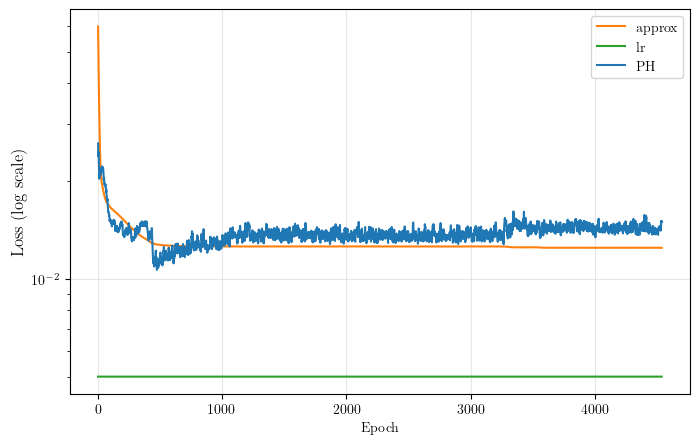

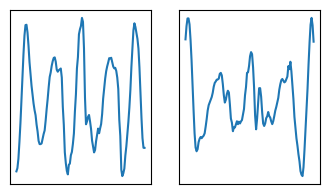

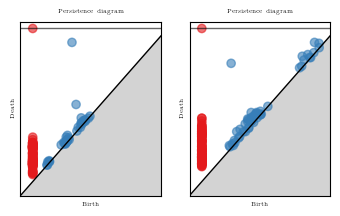

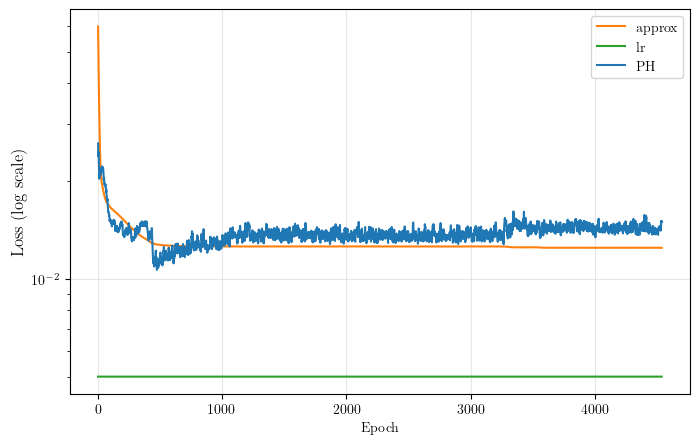

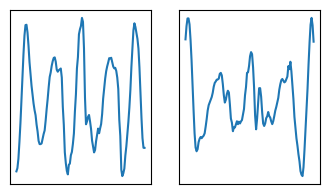

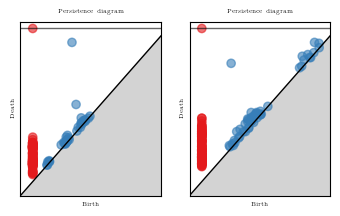

In [9]:
# 3. Fit Top-NMF on Gait Data
if X_gait is not None:
    n_components_gait = 2
    embedding_dim_gait = 10
    target_periodicity_gait = [1.0] + [None] * (n_components_gait - 1)

    model_gait = TopologicalNMF(
        n_components=n_components_gait,
        device=device,
        random_state=42,
        use_embedding=True,
    )

    monitor_gait = FitMonitor(
        show=["loss", "basis", "PH"],
        interval=100,
        factor=1.0,
        grid=(1, n_components_gait),
    )

    model_gait.fit(
        X_gait,
        n_iterations=5000,
        lr=0.005,
        lambda_apx=1.0,
        lambda_top=0.01,
        target_periodicity=target_periodicity_gait,
        start_epoch_topological=0,
        embedding_dim=embedding_dim_gait,
        n_periods=5,
        init_method="nndsvda",
        verbose=False,
        monitor=monitor_gait,
    )


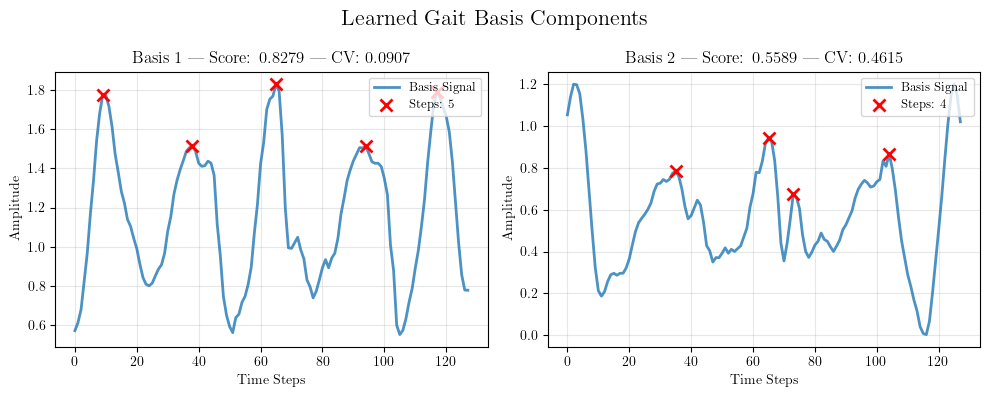

In [10]:
# 4. Visualize Learned Gait Basis (with Step Peaks & CV)
if X_gait is not None:
    tau_gait = int(model_gait.V.shape[1] / (5 * (embedding_dim_gait + 1)))

    fig, axes = plt.subplots(1, n_components_gait, figsize=(5 * n_components_gait, 4))
    fig.suptitle("Learned Gait Basis Components", fontsize=16)

    for i, ax in enumerate(axes):
        signal = model_gait.V[i].detach().cpu().numpy()
        time_steps = np.arange(len(signal))

        # 1. Plot Basis
        ax.plot(time_steps, signal, linewidth=2, color="tab:blue", alpha=0.8, label="Basis Signal")

        # 2. Find Peaks (Dynamic prominence based on signal range)
        signal_range = np.max(signal) - np.min(signal)
        dynamic_prominence = signal_range * 0.20
        peaks, _ = find_peaks(signal, distance=5, prominence=dynamic_prominence)

        # 3. Calculate Periodicity & CV
        score = compute_periodicity_score(model_gait.V[i], dim=embedding_dim_gait + 1, tau=tau_gait)

        if len(peaks) > 1:
            intervals = np.diff(peaks)
            cv_intervals = np.std(intervals) / np.mean(intervals)
        else:
            cv_intervals = 0.0

        # 4. Mark Peaks
        if len(peaks) > 0:
            ax.plot(peaks, signal[peaks], "rx", markersize=8, markeredgewidth=2, label=f"Steps: {len(peaks)}")

        ax.set_title(f"Basis {i + 1} | Score: {score:.4f} | CV: {cv_intervals:.4f}")
        ax.grid(alpha=0.3)
        ax.set_ylabel("Amplitude")
        ax.set_xlabel("Time Steps")
        ax.legend(loc="upper right", fontsize=9)

    plt.tight_layout()
    plt.show()


---
## Part B -- Unimodal basis (1-D cubical persistence)

Each basis vector should be **one connected blob** ($b_0 = 1$). On a 1-D
signal, vertex-mode superlevel cubical persistence measures how many distinct
local maxima a basis carries.

Here we use the weighted total squared persistence

$$
WTP_p^{(k)}(v) = \sum_{(b,d) \in PH_k^{\mathrm{fin}}(v)} (1-d)^p (d-b)^2,
\qquad p \ge 0.
$$

In B.1 we set $k=0$ and $p=2$, i.e. $WTP_2^{(0)}$. The death weight reduces the
influence of tiny low-level mergers and focuses the penalty on persistent
secondary peaks, yielding a unimodal shape without explicitly matching an empty
target diagram.


### B.1 Synthetic example -- Gaussian peak mixtures

Four ground-truth atoms, each a unimodal Gaussian centred at a distinct
position over $[0, 1]$. We observe six mixtures with random non-negative
coefficients and a small amount of detector-style noise. Top-NMF minimises
$WTP_2^{(0)}$ on every basis, while standard NMF only minimises reconstruction
error.


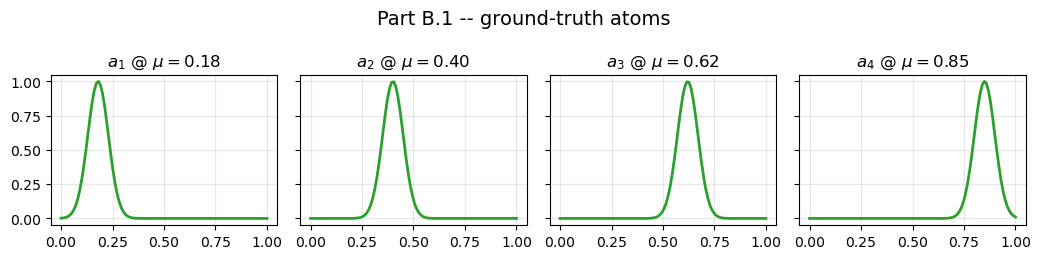

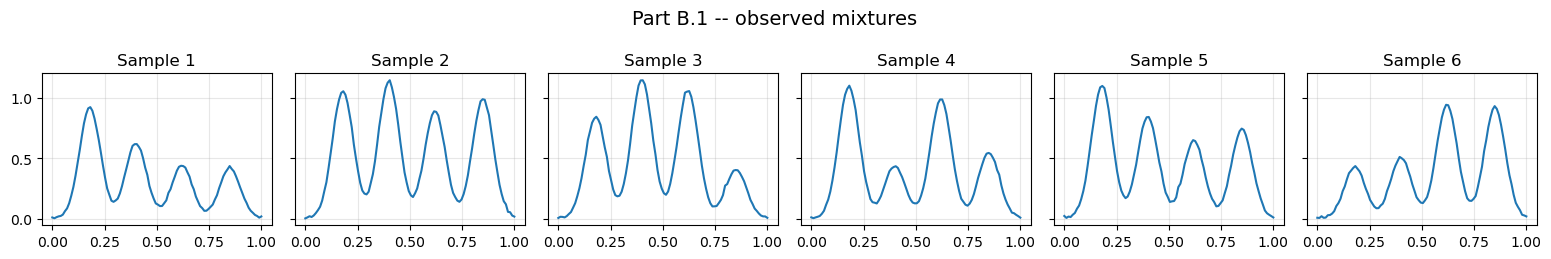

In [ ]:
T_B1 = 100
x_B1 = np.linspace(0, 1, T_B1)
centers_B1 = np.array([0.18, 0.40, 0.62, 0.85])
sigma_B1 = 0.05
atoms_B1 = np.stack([
    np.exp(-((x_B1 - c) ** 2) / (2 * sigma_B1 ** 2)) for c in centers_B1
], axis=0).astype(np.float32)
n_components_B1 = atoms_B1.shape[0]

rng = np.random.default_rng(0)
n_samples_B1 = 6
W_true_B1 = rng.uniform(0.4, 1.2, size=(n_samples_B1, n_components_B1)).astype(np.float32)
X_B1 = (W_true_B1 @ atoms_B1).astype(np.float32)
X_B1 += 0.01 * np.abs(rng.standard_normal(X_B1.shape).astype(np.float32))
X_B1 = np.clip(X_B1, 0, None)

fig, axes = plt.subplots(1, n_components_B1, figsize=(2.6 * n_components_B1, 2.6), sharey=True)
fig.suptitle("Part B.1 -- ground-truth atoms", fontsize=14)
for i, ax in enumerate(axes):
    ax.plot(x_B1, atoms_B1[i], lw=2, color="tab:green")
    ax.set_title(f"$a_{i + 1}$ @ $\\mu={centers_B1[i]:.2f}$")
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, n_samples_B1, figsize=(2.6 * n_samples_B1, 2.6), sharey=True)
fig.suptitle("Part B.1 -- observed mixtures", fontsize=14)
for i, ax in enumerate(axes):
    ax.plot(x_B1, X_B1[i], lw=1.5, color="tab:blue")
    ax.set_title(f"Sample {i + 1}")
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


#### Fit Top-NMF and standard NMF

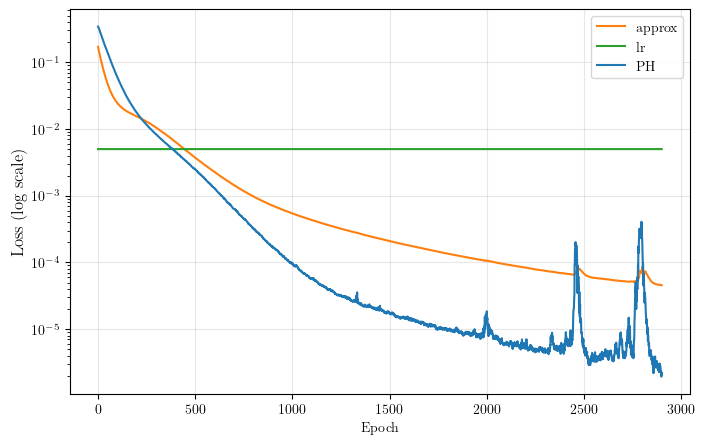

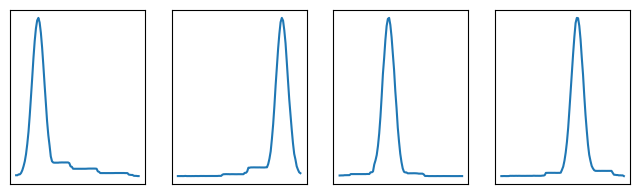

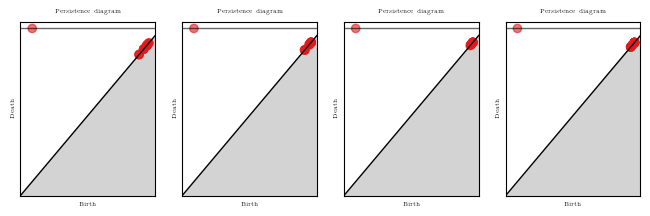

  0%|          | 0/3000 [00:00<?, ?it/s]

In [ ]:
cubical_B1 = CubicalComplex(superlevel=True, dim=1, mode="V")
# TopologicalNMF currently calls ph_loss_fn when target_diagrams is not None;
# WTP ignores these placeholders and directly evaluates the computed diagram.
target_diagrams_B1 = [None]

model_B1 = TopologicalNMF(
    n_components=n_components_B1,
    device=device,
    random_state=0,
    complex=cubical_B1,
    ph_loss_fn=weighted_total_squared_persistence_loss,
    ph_loss_params={"p": 2.0},
    data_shape=(T_B1,),
    use_embedding=False,
)
monitor_B1 = FitMonitor(
    show=["loss", "basis", "PH"],
    interval=100,
    factor=1.0,
    grid=(1, n_components_B1),
    PHmode="V",
    superlevel=True,
    save_video=True,
)
model_B1.fit(
    X_B1,
    n_iterations=3000,
    lr=0.005,
    lambda_top=0.5,
    PH_dims=[0],
    target_diagrams=target_diagrams_B1,
    init_method="nndsvdar",
    normalize_V_max=True,
    verbose=True,
    monitor=monitor_B1,
)
plt.close("all")

V_top_B1 = model_B1.get_components()
W_top_B1 = model_B1.transform(X_B1)

nmf_B1 = NMF(n_components=n_components_B1, init="nndsvda", random_state=0, max_iter=10000)
W_nmf_B1 = nmf_B1.fit_transform(X_B1)
V_nmf_B1 = nmf_B1.components_


In [ ]:
monitor_B1.save("unimodal.mp4", show=["basis","PH"], fps=5)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1600, 225) to (1600, 240) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Video saved: unimodal.mp4


#### Compare learned bases

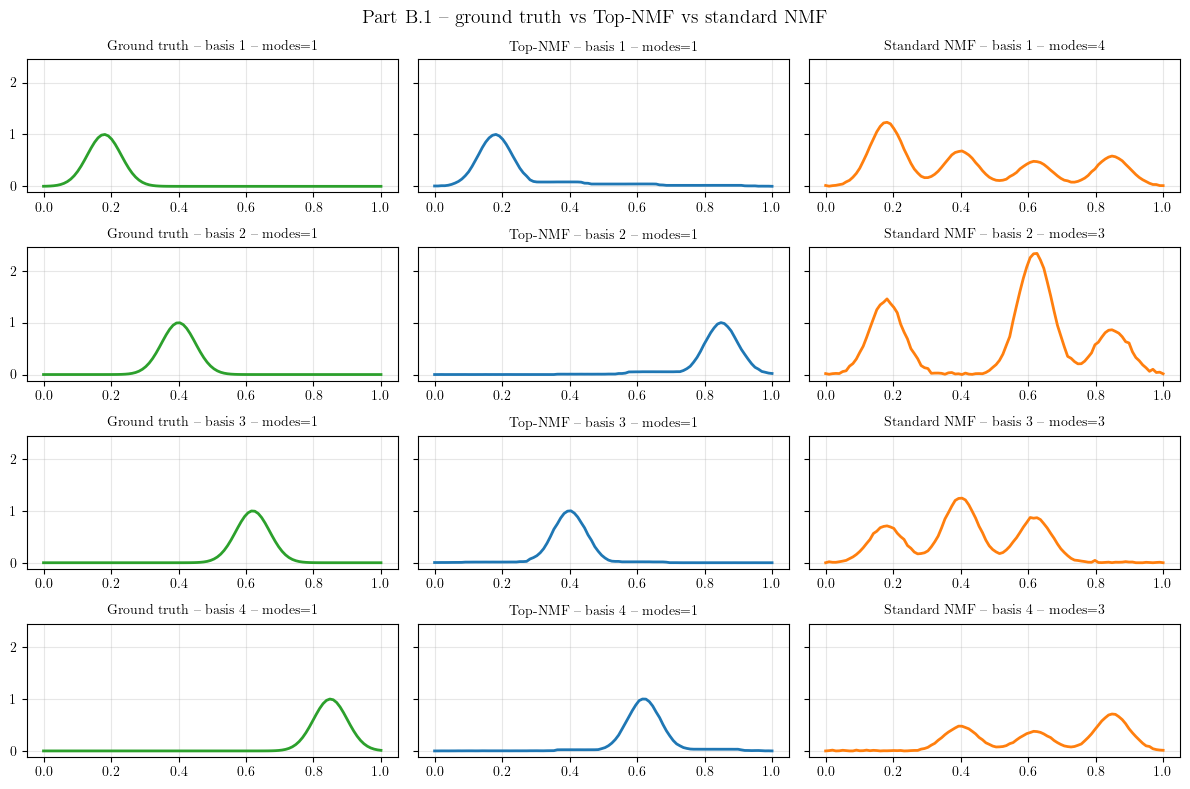

In [ ]:
fig, axes = plt.subplots(n_components_B1, 3, figsize=(12, 8), sharey=True)
fig.suptitle("Part B.1 -- ground truth vs Top-NMF vs standard NMF", fontsize=14)
columns_B1 = [
    ("Ground truth", atoms_B1, "tab:green"),
    ("Top-NMF", V_top_B1, "tab:blue"),
    ("Standard NMF", V_nmf_B1, "tab:orange"),
]
for col, (label, V, color) in enumerate(columns_B1):
    for row in range(n_components_B1):
        ax = axes[row, col]
        ax.plot(x_B1, V[row], lw=2, color=color)
        ax.set_title(f"{label} -- basis {row + 1} -- modes={count_modes(V[row])}", fontsize=10)
        ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


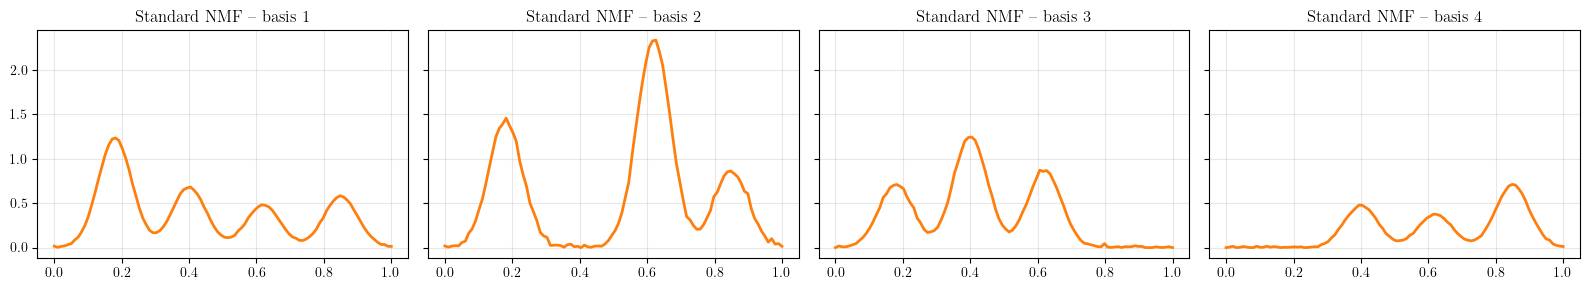

In [ ]:
fig, axes = plt.subplots(1, V_nmf_B1.shape[0], figsize=(4 * V_nmf_B1.shape[0], 3), sharey=True)

if V_nmf_B1.shape[0] == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    ax.plot(x_B1, V_nmf_B1[i], lw=2, color="tab:orange")
    ax.set_title(f"Standard NMF -- basis {i + 1}")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Quantitative comparison

In [ ]:
mae_top_B1, _, _ = basis_peak_position_mae(V_top_B1, x_B1, centers_B1)
mae_nmf_B1, _, _ = basis_peak_position_mae(V_nmf_B1, x_B1, centers_B1)


def wtp0_2_values_B1(V: np.ndarray) -> list:
    values = []
    for v in V:
        tensor_v = torch.as_tensor(v, dtype=torch.float, device=device)
        diagrams = cubical_B1(tensor_v)
        loss = weighted_total_squared_persistence_loss(diagrams, [0], device=device, p=2.0)
        values.append(float(loss.detach().cpu()))
    return values

wtp_top_B1 = wtp0_2_values_B1(V_top_B1)
wtp_nmf_B1 = wtp0_2_values_B1(V_nmf_B1)

print(f"""Modes per basis (target = 1, lower mixture means more multi-peak leakage):
  Ground truth : {[count_modes(a) for a in atoms_B1]}
  Top-NMF      : {[count_modes(v) for v in V_top_B1]}
  Standard NMF : {[count_modes(v) for v in V_nmf_B1]}

WTP_2^{(0)} per basis (lower = fewer persistent secondary peaks):
  Top-NMF      : {[round(v, 5) for v in wtp_top_B1]}
  Standard NMF : {[round(v, 5) for v in wtp_nmf_B1]}

Atom recovery (cosine similarity, higher = better):
  Top-NMF      : {atom_recovery_score(V_top_B1, atoms_B1):.3f}
  Standard NMF : {atom_recovery_score(V_nmf_B1, atoms_B1):.3f}

Peak-position MAE (lower = better):
  Top-NMF      : {mae_top_B1:.3f}
  Standard NMF : {mae_nmf_B1:.3f}

Reconstruction RMSE:
  Top-NMF      : {reconstruction_rmse(X_B1, W_top_B1, V_top_B1):.4f}
  Standard NMF : {reconstruction_rmse(X_B1, W_nmf_B1, V_nmf_B1):.4f}""")
